# Building a model with advanced packages

This notebook starts from a calibrated base model of the synthetic valley and converts its simple boundary conditions into MODFLOW 6 *advanced packages*. Recharge becomes the Unsaturated Zone Flow (UZF) package, pumping wells become Multi-Aquifer Wells (MAW), the river (RIV) becomes the Streamflow Routing (SFR) package, the high-conductivity lake becomes the Lake (LAK) package, and a Water Mover (MVR) package routes water between them. The model is then run and the results are plotted and compared with the calibration targets.

Set `sample_frequency` below to `"annual"` or `"monthly"` to choose the temporal resolution.

> **Model reference.** The synthetic valley model used in these notebooks is described in Hughes, J.D., Langevin, C.D., Paulinski, S.R., Larsen, J.D., and Brakenhoff, D., 2024, FloPy workflows for creating structured and unstructured MODFLOW models: Groundwater, v. 62, no. 1, p. 124–139, https://doi.org/10.1111/gwat.13327.

## The big picture: what "advanced packages" do

This notebook takes a working, calibrated flow model and upgrades its boundary conditions from *simple* to *advanced*. The same mental model runs through every step, so it is worth a minute before the code.

**Simple vs. advanced packages**

The base model represents external stresses with **simple boundary conditions** — recharge (`RCH`), wells (`WEL`), and a river (`RIV`) — each of which just adds or removes water from a cell at a prescribed rate. **Advanced packages** replace these with small physical models that compute the exchange themselves:

| Simple (base) | Advanced (upgrade) | What the upgrade adds |
|---|---|---|
| `RCH` recharge | `UZF` Unsaturated Zone Flow | resolves infiltration (e.g. rainfall) into ET, change in soil moisture (storage), and recharge |
| `WEL` wells | `MAW` Multi-Aquifer Well | a real wellbore screened across layers, solving for one head per well |
| `RIV` river | `SFR` Streamflow Routing | routes flow reach-to-reach and exchanges it with the aquifer |
| high-K lake cells | `LAK` Lake | solves for lake stage and its exchange with the groundwater |

The **Water Mover** (`MVR`) facilitates the transfer of water between packages, whether the result of managed (e.g., irrigation) or natural (e.g., streams entering lakes) connections. Any number of arbitrary connections between features is supported. For example, infiltration rejected by the `UZF` package can be routed to a stream reach or lake. 

**The toggles**

Each upgrade is guarded by a flag (`isUZF`, `isMAW`, `isSFR`, `isLake`, `isMover`) set in one place below. `True` builds the advanced package and removes the simple one it replaces; `False` keeps the base boundary condition. The same flags are reused later to read the right output and draw the right plots, so you can turn an upgrade on or off and re-run to see exactly what it changes.

**The recurring FloPy pattern**

Every advanced package is defined with the same three ingredients, so once you have seen one you have seen them all:

- **packagedata** — the static, per-feature properties (one row per UZF cell, well, stream reach, or lake);
- **connectiondata** — how features connect to the grid or to each other (which cells a well screen touches, how stream reaches link up);
- **perioddata** (stress period data) — the values that change through time (rainfall, pumping rates, evaporation), keyed by stress period.

**Time: calibration then prediction**

The simulation has a calibration period followed by two roughly 10-year transient **prediction** periods. After the run, the results are compared against calibration targets (head residuals) and then used to look at pumping-induced drawdown, streamflow capture, and lake stage.

**Units**

The base model is in **feet** and **days**. Forcing data arrive in inches and are converted to feet with `in2ft`; volumetric flows are divided by `86400` (seconds per day) to report **cubic feet per second (cfs)**.

Keep this picture — *simple → advanced boundary conditions, wired together by the Mover, each built from packagedata / connectiondata / perioddata* — in mind as you go.

## Imports and setup

Import FloPy and the supporting libraries, then choose the temporal resolution (`sample_frequency`) and set the model name and workspaces used throughout the notebook.

In [1]:
%matplotlib inline
import pathlib as pl
import pickle

import flopy
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import numpy as np
import pandas as pd
import xarray as xa

from IPython.display import Image, display
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)


In [2]:
sample_frequency = "annual"  # monthly or annual
name = "sv"

## Advanced package toggles

The boolean flags below control which advanced packages are built and used throughout the notebook. Set a flag to `True` to build and use the corresponding advanced package, or `False` to keep the base model's simple boundary condition instead. The flags are also referenced later when post-processing and plotting the results, so set them here in one place rather than next to each package.

- `isUZF` — Unsaturated Zone Flow (UZF) package; replaces the recharge (RCH) package.
- `isMAW` — Multi-Aquifer Well (MAW) package; replaces the simple well (WEL) package.
- `isSFR` — Streamflow Routing (SFR) package; replaces the river (RIV) package. Also selects SFR vs. RIV output when reading budgets and plotting streamflow.
- `isLake` — Lake (LAK) package; replaces the high-K lake cells and the lake EVT observations. Also controls lake-stage post-processing.
- `isMover` — Water Mover (MVR) package; routes rejected UZF infiltration to the lake and stream network. Only takes effect when `isUZF` is also `True`.


In [3]:
# Toggle which advanced packages are built and used below.
# Set a flag to True to build/use the advanced package, or False to keep the
# base model's simple boundary condition. These flags are also referenced when
# post-processing and plotting the results.

isUZF = True  # Unsaturated Zone Flow package (replaces RCH)
isMAW = True  # Multi-Aquifer Well package (replaces WEL)
isSFR = True  # Streamflow Routing package (replaces RIV)
isLake = True  # Lake package (replaces high-K lake cells)
isMover = True  # Mover package - mover only added if isUZF is also True

In [4]:
# load the simple model setup
base_ws = pl.Path(f"../data/synthetic-valley/synthetic-valley-base-{sample_frequency}")
advanced_ws = pl.Path(f"models/synthetic-valley-advanced-{sample_frequency}")

In [5]:
# unit conversion factor
in2ft = 1.0 / 12.0

## Load the temporal data

Read the time-varying forcing data (precipitation, evapotranspiration, and pumping rates) for the selected sample frequency from a parquet file.

In [6]:
idx_end_calibration = 0
if sample_frequency == "monthly":
    idx_end_period2 = 120
    idx_end_period3 = 240
elif sample_frequency == "annual":
    idx_end_period2 = 10
    idx_end_period3 = 20
else:
    raise ValueError(f"invalid sample_frequency: '{sample_frequency}'")

In [7]:
path = pl.Path(
    f"../data/synthetic-valley/data/temporal_data_{sample_frequency}.parquet"
)
temporal_df = pd.read_parquet(path)

In [8]:
temporal_df

,PRCP (Inches),lake et (inches),land et (inches),netrch lake (inches),netrch land (inches),reilly,vc,perlen
2006-01-01,0.111791,0.083987,0.061356,0.027805,0.050436,0.0,0.0,16071
2007-01-01,0.125945,0.102647,0.074988,0.023298,0.050957,-67000.0,-268000.0,365
2008-01-01,0.074027,0.035462,0.025907,0.038565,0.048121,-67000.0,-268000.0,365
2009-01-01,0.120164,0.093684,0.068440,0.026480,0.051724,-67000.0,-268000.0,366
2010-01-01,0.133205,0.114823,0.083883,0.018383,0.049322,-67000.0,-268000.0,365
2011-01-01,0.107123,0.074259,0.054250,0.032864,0.052874,-67000.0,-268000.0,365
2012-01-01,0.126575,0.103677,0.075741,0.022898,0.050835,-67000.0,-268000.0,365
2013-01-01,0.097350,0.061487,0.044919,0.035862,0.052431,-67000.0,-268000.0,366
2014-01-01,0.124219,0.099853,0.072947,0.024366,0.051272,-67000.0,-268000.0,365
2015-01-01,0.126219,0.103094,0.075315,0.023125,0.050904,-67000.0,-268000.0,365


## Define the stress period boundaries

Set the simulation start date and compute the elapsed time (in days) at the end of the calibration period and the two transient prediction periods.

In [9]:
start_date = pd.to_datetime("1962-01-01 00:00:00")
start_date_time = str(start_date).replace(" ", "T")

end_calibration = temporal_df.index[idx_end_calibration]
end_period_two = temporal_df.index[idx_end_period2]
end_period_three = temporal_df.index[idx_end_period3]

end_periods = [end_calibration, end_period_two, end_period_three]
end_periods

[Timestamp('2006-01-01 00:00:00'),
 Timestamp('2016-01-01 00:00:00'),
 Timestamp('2026-01-01 00:00:00')]

In [10]:
totim_end = [float((end_calibration - start_date).days)]
totim_end += [float((end_period_two - start_date).days)]
totim_end += [float((end_period_three - start_date).days)]
totim_end

[16071.0, 19723.0, 23376.0]

## Load the spatial data

Open the "truth" netCDF dataset to get the lake location and compute the lake surface area, both of which are used when building the advanced packages.

In [11]:
nc_path = pl.Path("../data/synthetic-valley/data/synthetic_valley_truth.nc")
nc_ds = xa.open_dataset(nc_path)
lake_location = nc_ds["lake_location"].to_numpy()
lake_area = float(lake_location.sum()) * 500.0 * 500.0

## Load the existing base model

Load the calibrated base simulation and its groundwater flow (GWF) model, and read the grid dimensions. The advanced packages added below replace the base model's simple boundary conditions.

In [12]:
sim = flopy.mf6.MFSimulation.load(sim_name=name, sim_ws=base_ws, write_headers=False)

loading simulation...
  loading simulation name file...
  loading tdis package...
  loading model gwf6...
    loading package dis...
    loading package ic...
    loading package npf...
    loading package sto...
    loading package rch...
    loading package evt...
    loading package riv...
    loading package wel...
    loading package wel...
    loading package oc...
    loading package obs...
  loading solution package sv...


In [13]:
nper = sim.tdis.nper.array
gwf = sim.get_model(name)
nlay, nrow, ncol = gwf.dis.nlay.array, gwf.dis.nrow.array, gwf.dis.ncol.array
shape2d = (nrow, ncol)
shape3d = (nlay, nrow, ncol)

In [14]:
izone = np.zeros(shape3d, dtype=int)
idx = lake_location == 1
izone[0][idx] = 1

In [15]:
botm = gwf.dis.botm.array

In [16]:
# list the packages in the gwf model
gwf.get_package_list()

['DIS',
 'IC',
 'NPF',
 'STO',
 'RCH_0',
 'EVT_0',
 'RIV_OBS',
 'RIV-1',
 'PWELL',
 'PREDICTION',
 'OC',
 'GWF-OBS']

### Change the simulation workspace

Point the simulation at a new workspace so the advanced-packages version is written separately from the base model.

In [17]:
advanced_ws

WindowsPath('models/synthetic-valley-advanced-annual')

In [18]:
sim.set_sim_path(advanced_ws)

## Convert the recharge to a UZF package

Replace the recharge (RCH) package with the Unsaturated Zone Flow (UZF) package, which routes precipitation and evapotranspiration through an unsaturated column above the water table. Rejected or discharged UZF water can be passed to other packages by the Mover.

In [19]:
# use the vertical hydraulic conductivity to define vks for the uzf package

k33 = gwf.npf.k33.array

In [20]:
# create uzf packagedata
# <ifno> <cellid> <landflag> <ivertcon> <surfdep> <vks> <thtr> <thts> <thti> <eps> [<boundname>]

packagedata = []
ifno = 0
for i in range(nrow):
    for j in range(ncol):
        if lake_location[i, j] == 1:
            continue
        cellid = (0, i, j)
        packagedata.append(
            (
                ifno,
                cellid,
                1,
                0,
                1.0,
                k33[cellid],
                0.05,
                0.25,
                0.1,
                3.5,
            )
        )

        ifno += 1

In [21]:
# uzf stress period data with rainfall and land evapotranspiration
# <ifno> <finf> <pet> <extdp> <extwc> <ha> <hroot> <rootact> [<aux(naux)>]

uzf_spd = {}
rain_tag = "PRCP (Inches)"
pet_tag = "land et (inches)"
for n in range(nper):
    row = temporal_df.iloc[n]
    rain = float(row[rain_tag]) * in2ft
    pet = float(row[pet_tag]) * in2ft
    spd = []
    for values in packagedata:
        ifno, cellid = values[:2]
        spd.append(
            (
                ifno,
                rain,
                pet,
                10.0,
                -999.0,
                -999.0,
                -999.0,
                -999.0,
            )
        )
    uzf_spd[n] = spd

In [22]:
if isUZF:
    print(gwf.rch.stress_period_data.dtype)
    print(gwf.rch.stress_period_data.array[0][0:5])
    #
    # print the rainfall rate in ft
    print('\n')
    print("rainfall rate in UZF: " + str(float(temporal_df.iloc[0][rain_tag]) * in2ft) + " ft/day")
    #print("rainfall rate in UZF: " + str(float(temporal_df.iloc[0][rain_tag])) + " in/day")
    print("ET rate in UZF: " + str(float(temporal_df.iloc[0][pet_tag]) * in2ft) + " ft/day")
    print('\n')
    

(numpy.record, [('cellid', 'O'), ('recharge', '<f8'), ('boundname', 'O')])
[((0, 0, 0), 0.00420296, 'land') ((0, 0, 1), 0.00420296, 'land')
 ((0, 0, 2), 0.00420296, 'land') ((0, 0, 3), 0.00420296, 'land')
 ((0, 0, 4), 0.00420296, 'land')]


rainfall rate in UZF: 0.009315952129093811 ft/day
ET rate in UZF: 0.005112989960937979 ft/day




In [23]:
# add uzf package to the gwf simulation
# set mover to True, simulated_et to True, and name the package "UZF-1"

if isUZF:
    uzf = flopy.mf6.ModflowGwfuzf(
        gwf,
        pname="UZF-1",
        mover=True,
        simulate_et=True,
        nuzfcells=len(packagedata),
        packagedata=packagedata,
        perioddata=uzf_spd,
    )

    # remove the existing recharge package
    gwf.remove_package("RCH_0")

## Confirm package swap

In [24]:
gwf.get_package_list()

['DIS',
 'IC',
 'NPF',
 'STO',
 'EVT_0',
 'RIV_OBS',
 'RIV-1',
 'PWELL',
 'PREDICTION',
 'OC',
 'GWF-OBS',
 'UZF-1']

## Convert the wells to a MAW package

Replace the simple well (WEL) package with the Multi-Aquifer Well (MAW) package, which represents wells screened across multiple layers and solves for a single head in each wellbore.

In [25]:
# well data
# key=well_name, layer0, layer1, row, and column

well_data = {
    "reilly": (3, 4, 5, 14),
    "vc": (3, 4, 32, 5),
}

In [26]:
for key, (k0, k1, i, j) in well_data.items():
    for k in range(k0, k1 + 1):
        cellid = (k, i, j)
        izone[cellid] = 3
izone[4, 34, 15] = 4

In [27]:
# create maw packagedata
# <ifno> <radius> <bottom> <strt> <condeqn> <ngwfnodes> [<aux(naux)>] [<boundname>]
# set the radius to 0.5 and use the "thiem" conductance equation

package_data = []
for idx, (key, value) in enumerate(well_data.items()):
    k0, k1, i, j = value
    package_data.append((idx, 0.5, float(botm[k1, i, j]), 0.0, "thiem", 2, key))
package_data

[(0, 0.5, -220.4, 0.0, 'thiem', 2, 'reilly'),
 (1, 0.5, -271.72, 0.0, 'thiem', 2, 'vc')]

In [28]:
# create maw connectiondata
# <ifno> <icon> <cellid> <scrn_top> <scrn_bot> <hk_skin> <radius_skin>

connection_data = []
for idx, (key, value) in enumerate(well_data.items()):
    k0, k1, i, j = value
    for jdx, k in enumerate(range(k0, k1 + 1)):
        cellid = (k, i, j)
        top = float(botm[k - 1, i, j])
        bot = float(botm[k, i, j])
        connection_data.append((idx, jdx, (k, i, j), top, bot, -999.0, -999.0))

connection_data

[(0, 0, (3, 5, 14), -50.69, -136.13, -999.0, -999.0),
 (0, 1, (4, 5, 14), -136.13, -220.4, -999.0, -999.0),
 (1, 0, (3, 32, 5), -50.71, -161.21, -999.0, -999.0),
 (1, 1, (4, 32, 5), -161.21, -271.72, -999.0, -999.0)]

In [29]:
# create maw stress period data
# maw wells are inactive in stress period 1

maw_spd = {0: [(idx, "status", "inactive") for idx in range(len(well_data))]}
for n in range(1, nper):
    if n == 1:
        spd = [(idx, "status", "active") for idx in range(len(well_data))]
    else:
        spd = []
    row = temporal_df.iloc[n]
    for idx, well_name in enumerate(well_data.keys()):
        spd.append((idx, "rate", float(row[well_name])))
    maw_spd[n] = spd

In [30]:
maw_spd

{0: [(0, 'status', 'inactive'), (1, 'status', 'inactive')],
 1: [(0, 'status', 'active'),
  (1, 'status', 'active'),
  (0, 'rate', -66999.99999999999),
  (1, 'rate', -267999.99999999994)],
 2: [(0, 'rate', -66999.99999999999), (1, 'rate', -267999.99999999994)],
 3: [(0, 'rate', -67000.0), (1, 'rate', -268000.0)],
 4: [(0, 'rate', -66999.99999999999), (1, 'rate', -267999.99999999994)],
 5: [(0, 'rate', -67000.0), (1, 'rate', -268000.0)],
 6: [(0, 'rate', -67000.0), (1, 'rate', -268000.0)],
 7: [(0, 'rate', -67000.0), (1, 'rate', -268000.0)],
 8: [(0, 'rate', -67000.00000000001), (1, 'rate', -268000.00000000006)],
 9: [(0, 'rate', -67000.00000000001), (1, 'rate', -268000.00000000006)],
 10: [(0, 'rate', -67000.0), (1, 'rate', -268000.0)],
 11: [(0, 'rate', -67000.0), (1, 'rate', -268000.0)],
 12: [(0, 'rate', -67000.00000000001), (1, 'rate', -268000.00000000006)],
 13: [(0, 'rate', -67000.0), (1, 'rate', -268000.0)],
 14: [(0, 'rate', -66999.99999999999), (1, 'rate', -267999.99999999994)

In [31]:
# remove the existing wel package and add maw package to the gwf simulation

if isMAW:
    gwf.remove_package("pwell")

    maw = flopy.mf6.ModflowGwfmaw(
        gwf,
        boundnames=True,
        nmawwells=len(well_data),
        packagedata=package_data,
        connectiondata=connection_data,
        perioddata=maw_spd,
        pname="pwell",
    )

## Convert the RIV package to an SFR package

Replace the river (RIV) package with the Streamflow Routing (SFR) package, which explicitly routes flow between connected stream reaches and exchanges water with the aquifer.

In [32]:
# get the existing river package

pak = gwf.get_package("RIV-1")

In [33]:
# get the river stress period data for stress period 1
# this will be used to define some sfr package data
# set nreaches to the length of the stress period data array

spd = pak.stress_period_data.get_data(0)
nreaches = len(spd)

In [34]:
for cellid, stage, cond, rbot, boundname in spd:
    izone[cellid] = 2

In [35]:
# calculate the bed gradient for each reach

rgrad = np.diff(spd["rbot"]) * (-1.0)
rgrad = np.array([float(rgrad[0])] + rgrad.tolist())

In [36]:
# create sfr packagedata and connection data
# <ifno> <cellid> <rlen> <rwid> <rgrd> <rtp> <rbth> <rhk> <man> <ncon> <ustrf> <ndv> [<aux(naux)>] [<boundname>]

delc = gwf.dis.delc.array
rwid = 30.0
rbth = 1.0
man = 0.03
ustrf = 1.0
ndv = 0
packagedata = []
connectiondata = []

for ifno, (cellid, stage, cond, rbot, boundname) in enumerate(spd):
    rconn = [ifno]
    ncon = 1
    if ifno > 0 and ifno < nreaches - 1:
        ncon += 1
    if ifno > 0:
        rconn.append(ifno - 1)
    if ifno < nreaches - 1:
        rconn.append(-(ifno + 1))
    connectiondata.append(rconn)
    rlen = float(delc[cellid[1]])
    rhk = float(cond) / (rwid * rlen)
    packagedata.append(
        (
            ifno,
            cellid,
            rlen,
            rwid,
            float(rgrad[ifno]),
            float(rbot),
            rbth,
            rhk,
            man,
            ncon,
            ustrf,
            ndv,
            boundname,
        )
    )

In [37]:
# create sfr observations

sfr_obs = [
    ("RIV-SWGW", "SFR", "RIV"),
    ("RIV-FLOW", "downstream-flow", nreaches - 1),
]
sfr_obs = {
    f"{name}.sfr.obs.csv": sfr_obs,
}

In [38]:
# add sfr package to the gwf simulation
# set time_conversion to 86400.0, mover to True, boundname to True, and name the package "SFR-1"

if isSFR:
    sfr = flopy.mf6.ModflowGwfsfr(
        gwf,
        time_conversion=86400.0,
        save_flows=True,
        mover=True,
        boundnames=True,
        nreaches=nreaches,
        packagedata=packagedata,
        connectiondata=connectiondata,
        pname="SFR-1",
    )

    # initialize the sfr observations

    sfr.obs.initialize(
        filename=f"{name}.sfr.obs",
        print_input=True,
        continuous=sfr_obs,
    )

    # remove the existing riv and river observation packages
    for pak_name in ("RIV-1", "RIV_OBS"):
        gwf.remove_package(pak_name)
else:
    print("isSFR = " + str(isSFR))

## Convert the high-K lake to a LAK package

Replace the high-conductivity cells that approximate the lake with the Lake (LAK) package, which simulates lake stage and its exchange with the groundwater system.

In [39]:
# create 3d lake_array array and set to 0 in lake location and -1 elsewhere

lake_array = np.full(shape3d, -1, dtype=int)
idx = lake_location == 1
lake_array[0, :, :][idx] = 0

# use get_lak_connections to create lake data and set bedleak to 1e-2
idomain, lake_connection_dict, lake_connection_data = (
    flopy.mf6.utils.get_lak_connections(
        gwf.modelgrid,
        lake_array,
        bedleak=1e-2,
    )
)


In [40]:
# Try viewing the lake location within the model doamin
# shape3d
# lake_location.shape

Note the use of the utility: `flopy.mf6.utils.get_lak_connection_data()`


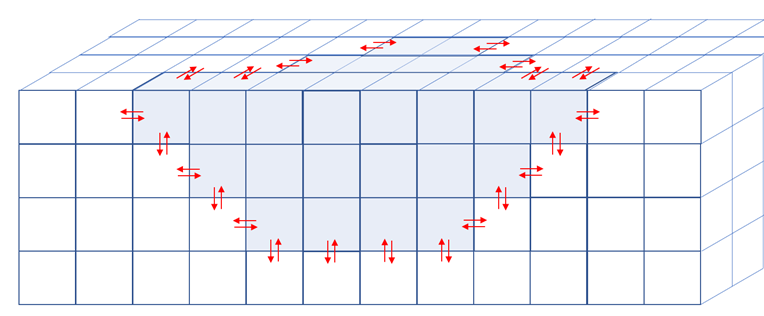

In [41]:
# set model idomain to new idomain if using the lake package, which will 
# deactivate the high-K lake cells in the base model

if isLake:
    gwf.dis.idomain = idomain
    print("Note the use of the utility: `flopy.mf6.utils.get_lak_connection_data()`")
    img = Image(filename='../../images/LAK_interactions.png')
    display(img)
else:
    print("isLake = " + str(isLake))


In [42]:
# create lake package data using value to define nlakeconn and set boundname to "lake_harbaugh"
# <ifno> <strt> <nlakeconn> [<aux(naux)>] [<boundname>]

lake_pakagedata = []
for key, value in lake_connection_dict.items():
    lake_pakagedata.append((int(key), 13.0, value, "lake_harbaugh"))
nlakes = len(lake_pakagedata)
lake_pakagedata

[(0, 13.0, 105, 'lake_harbaugh')]

In [43]:
# create lake observations

lake_obs = {
    f"{name}.lake.obs.csv": [
        ("LAKE-STAGE", "STAGE", "LAKE_HARBAUGH"),
        ("LAKE-SWGW", "LAK", "LAKE_HARBAUGH"),
    ]
}

In [44]:
# create lake stress period data with rainfall and evaporation

lake_spd = {}
rain_tag = "PRCP (Inches)"
pet_tag = "lake et (inches)"
for n in range(nper):
    row = temporal_df.iloc[n]
    rain = float(row[rain_tag]) * in2ft
    pet = float(row[pet_tag]) * in2ft
    lake_spd[n] = [(0, "rainfall", rain), (0, "evaporation", pet)]

In [45]:
# add lak package to the gwf simulation
# set mover to True, boundnames to True, and name the package "LAK-1"

if isLake:
    lak = flopy.mf6.ModflowGwflak(
        gwf,
        boundnames=True,
        print_input=True,
        print_stage=True,
        mover=True,
        pname="LAK-1",
        stage_filerecord=f"{name}.lak.hds",
        nlakes=nlakes,
        packagedata=lake_pakagedata,
        connectiondata=lake_connection_data,
        perioddata=lake_spd,
    )

    # initialize the lake observations
    lak.obs.initialize(
        filename=f"{name}.lak.obs",
        print_input=True,
        continuous=lake_obs,
    )

    # remove the existing EVT package
    gwf.remove_package("EVT_0")

In [46]:
# redefine existing groundwater flow observation file to remove the existing "lake" observations

if isLake:
    pak = gwf.get_package("GWF-OBS")

    # create a new groundwater observation dictionary
    gwf_obs = {}
    for key, value in pak.continuous.get_active_key_list():
        if key != "sv.lake.obs.csv":
            gwf_obs[key] = value.get_data().tolist()

    # remove the existing groundwater observation package
    gwf.remove_package("GWF-OBS")

    # create a new
    gwf_obs = flopy.mf6.ModflowUtlobs(gwf, print_input=True, continuous=gwf_obs)

## Add the Mover (MVR) package

Add the Water Mover (MVR) package to route water between the advanced packages, for example sending rejected UZF infiltration to the lake or the stream network.

In [47]:
perioddata = []
if isUZF and isMover:
    packages = [["uzf-1"], ["LAK-1"], ["SFR-1"]]
    for values in uzf.packagedata.array:
        ifno, cellid = values["ifno"], values["cellid"]
        i = cellid[1]
        if i < 20:
            dst = "LAK-1"
        else:
            dst = "SFR-1"
        perioddata.append(("uzf-1", int(ifno), dst, 0, "factor", 0.10))

    maxmvr = len(perioddata)
    perioddata_dict = {
        0: perioddata,
    }

    mvr = flopy.mf6.ModflowGwfmvr(
        gwf,
        maxmvr=maxmvr,
        maxpackages=len(packages),
        packages=packages,
        perioddata=perioddata_dict,
    )

## Write and run the simulation

Write the MODFLOW 6 input files for the advanced-packages model and run the simulation.

In [48]:
sim.write_simulation()

writing simulation...
  writing simulation name file...
  writing simulation tdis package...
  writing solution package sv...
  writing model sv...
    writing model name file...
    writing package dis...
    writing package ic...
    writing package npf...
    writing package sto...
    writing package prediction...
    writing package oc...
    writing package uzf-1...
    writing package pwell...
    writing package sfr-1...
    writing package obs_0...
    writing package lak-1...
    writing package obs_1...
    writing package obs_2...
    writing package mvr...


In [49]:
sim.run_simulation()

FloPy is using the following executable to run the model: ..\..\..\..\.pixi\envs\default\Scripts\mf6.exe
                               MODFLOW 6 EXTENDED
                U.S. GEOLOGICAL SURVEY MODULAR HYDROLOGIC MODEL
                        VERSION 6.8.0.dev0+4c1fe72.dirty
                               ***DEVELOP MODE***

   MODFLOW 6 compiled Sep 02 2026 17:48:03 with Intel(R) Fortran Intel(R) 64
  Compiler Classic for applications running on Intel(R) 64, Version 2021.12.0
                             Build 20240222_000000

This software is preliminary or provisional and is subject to 
revision. It is being provided to meet the need for timely best 
science. The software has not received final approval by the U.S. 
Geological Survey (USGS). No warranty, expressed or implied, is made 
by the USGS or the U.S. Government as to the functionality of the 
software and related material nor shall the fact of release 
constitute any such warranty. The software is provided on the 
condition 

(True, [])

## Plot the results

Visualize the simulated results and compare them with the calibration targets.

### Model properties

Maps of hydraulic conductivity, bottom elevation, and cell thickness by layer.

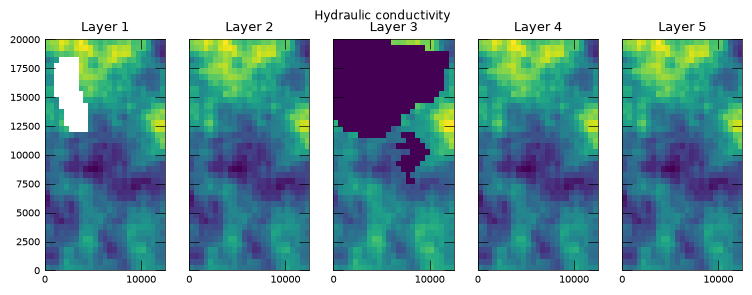

In [50]:
with flopy.plot.styles.USGSMap():
    fig, axs = plt.subplots(1, 5, figsize=(9, 3), sharey=True)
    fig.suptitle("Hydraulic conductivity")

    for idx in range(nlay):
        ax = axs[idx]
        mm = flopy.plot.PlotMapView(model=gwf, layer=idx, ax=ax)
        mm.plot_array(gwf.npf.k.array[idx], masked_values=[2000000.0])
        ax.set_title(f"Layer {idx + 1}")

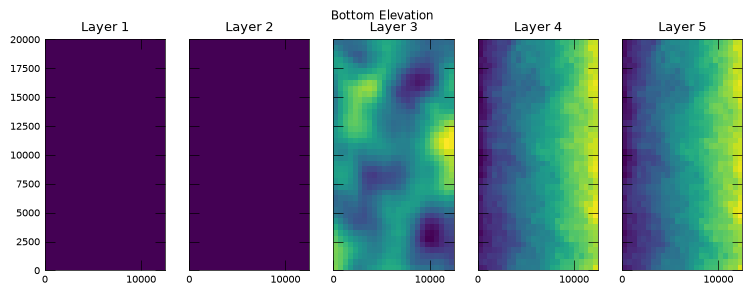

In [51]:
with flopy.plot.styles.USGSMap():
    fig, axs = plt.subplots(1, 5, figsize=(9, 3), sharey=True)
    fig.suptitle("Bottom Elevation")

    for idx in range(nlay):
        ax = axs[idx]
        mm = flopy.plot.PlotMapView(model=gwf, layer=idx, ax=ax)
        mm.plot_array(gwf.dis.botm.array[idx])
        ax.set_title(f"Layer {idx + 1}")

In [108]:
print(gwf.dis.botm.array[0, 10:15, 10:15])
print(gwf.dis.botm.array[1, 10:15, 10:15])

[[-5. -5. -5. -5. -5.]
 [-5. -5. -5. -5. -5.]
 [-5. -5. -5. -5. -5.]
 [-5. -5. -5. -5. -5.]
 [-5. -5. -5. -5. -5.]]
[[-15. -15. -15. -15. -15.]
 [-15. -15. -15. -15. -15.]
 [-15. -15. -15. -15. -15.]
 [-15. -15. -15. -15. -15.]
 [-15. -15. -15. -15. -15.]]


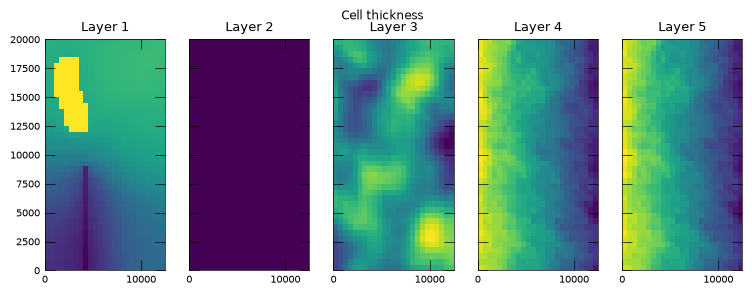

In [52]:
with flopy.plot.styles.USGSMap():
    fig, axs = plt.subplots(1, 5, figsize=(9, 3), sharey=True)
    fig.suptitle("Cell thickness")
    z = gwf.modelgrid.cell_thickness

    for idx in range(nlay):
        ax = axs[idx]
        mm = flopy.plot.PlotMapView(model=gwf, layer=idx, ax=ax)
        mm.plot_array(z[idx])
        ax.set_title(f"Layer {idx + 1}")

### Simulated heads and drawdown

A helper to retrieve heads at a given time (substituting lake stage in the lake cells), followed by the head and drawdown maps for each period.

In [53]:
def get_heads(totim):
    hds = gwf.output.head().get_data(totim=totim)
    if isLake:
        stage = gwf.lak.output.stage().get_data(totim=totim)
        h1 = hds[0]
        stage = np.full(shape2d, stage[0], dtype=float)
        idx = lake_location == 1
        h1[idx] = stage[idx]
        hds[0, :, :] = h1
    return hds

In [54]:
levels = np.arange(2, 20.0, 2)

#### Calibration

Simulated heads at the end of the calibration period, compared with the calibration targets.

In [55]:
totim = totim_end[0]
hds = get_heads(totim)

In [56]:
v = nc_ds["head_layer2"].values
v.min(), v.max(), v.mean()

(np.float64(-0.02295405103610612),
 np.float64(13.753982027294631),
 np.float64(9.032852049989534))

In [57]:
for k in range(nlay):
    diff = hds[k] - nc_ds[f"head_layer{k + 1}"].values
    print(f"{k + 1}: {diff.min()} {diff.max()} {diff.mean()}")

1: -1.021405182655144e-12 1.0889067425523535e-12 1.3601484522007822e-14
2: -1.021405182655144e-12 1.0871303857129533e-12 1.8222021114233656e-14
3: -5.329070518200751e-13 5.169198402654729e-13 8.50992193379696e-15
4: -1.8118839761882555e-13 2.5934809855243657e-13 2.095490447828752e-15
5: -1.687538997430238e-13 2.469136006766348e-13 2.091493644940101e-15


In [58]:
if sample_frequency == "monthly":
    for k in range(nlay):
        nc_ds[f"head_layer{k + 1}"].values = hds[k]
        nc_ds[f"izone{k + 1}"] = (("y", "x"), izone[k])
    temp_path = nc_path.parent / "temp.nc"
    nc_ds.to_netcdf(temp_path)

    temp_path.rename(nc_path)

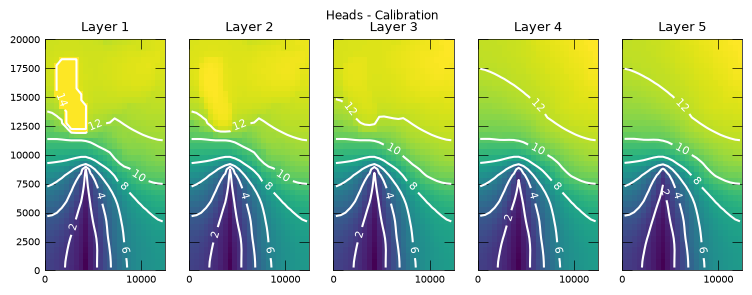

In [59]:
with flopy.plot.styles.USGSMap():
    fig, axs = plt.subplots(1, 5, figsize=(9, 3), sharey=True)
    fig.suptitle("Heads - Calibration")

    for idx in range(nlay):
        ax = axs[idx]
        mm = flopy.plot.PlotMapView(model=gwf, layer=idx, ax=ax)
        mm.plot_array(hds)
        cs = mm.contour_array(hds, colors="white", levels=levels)
        plt.clabel(cs, inline=True, fontsize=8)
        ax.set_title(f"Layer {idx + 1}")

**What to look for.** These are the simulated heads at the end of the calibration period, contoured by layer. Compare them with the layer-by-layer differences from the "truth" dataset printed just above: a well-calibrated model reproduces the observed head field closely. The residual maps a few cells down quantify where the fit is high or low.

**Inspecting the budget.** The cell below lists the flow terms MODFLOW saved in the cell-by-cell budget file and then picks the right label for the surface-water exchange — `"sfr"` when the SFR package is active, `"riv"` otherwise — so the post-processing below works no matter which package toggles are on.

In [60]:
# list the flow terms saved in the cell-by-cell budget file, then choose the
# label for the surface-water exchange: "sfr" when the SFR package is active,
# "riv" otherwise
budget = gwf.output.budget()
record_names = [r.strip() for r in np.array(budget.get_unique_record_names()).astype(str)]
print("Available budget terms:", record_names)

riv_text = "sfr" if isSFR else "riv"
v = budget.get_data(text=riv_text, totim=totim)[0]["q"]
print(f"\nUsing '{riv_text}' for the surface-water exchange term")
print(f"River infiltration everywhere positive: {np.all(v > 0)}\n{v}")

Available budget terms: ['STO-SS', 'FLOW-JA-FACE', 'DATA-SPDIS', 'WEL', 'MAW', 'SFR', 'LAK', 'UZF-GWRCH']

Using 'sfr' for the surface-water exchange term
River infiltration everywhere positive: False
[-111102.66005264  -85597.11978316  -92306.22032677  -95229.099878
  -88783.30085832  -80655.23065906  -75810.48328333  -71264.09586477
  -68024.7456875   -65731.48225681  -66935.32915606  -67235.02853449
  -70946.71915828  -70659.06049132  -68726.16342038  -67602.95064533
  -67248.57766937  -73517.91364898]


##### Calculate the residuals

Compute the difference between simulated and observed heads at the water-table and lower-aquifer observation wells, and summarize the error statistics.

In [61]:
obs_path = pl.Path("../data/synthetic-valley/data")
with open(obs_path / "obs_data.pkl", "rb") as f:
    obs_rc_locs, well_depth, aq_layer = pickle.load(f)

cal_loc_wt = [(0, i, j) for i, j in obs_rc_locs]
cal_loc_aq = [(aq_layer[idx], i, j) for idx, (i, j) in enumerate(obs_rc_locs)]

In [62]:
wt_obs = []
aq_layer = []
aq_obs = []
for idx, (i, j) in enumerate(obs_rc_locs):
    iloc = (i, j)
    tag = "head_layer1"
    wt_obs.append(float(nc_ds[tag].values[iloc]))
    wz = well_depth[idx]
    zcell = np.array(botm)[:, i, j]
    klay = 0
    for kk in range(1, nlay):
        z0 = zcell[kk - 1]
        z1 = zcell[kk]
        if wz < z0 and wz >= z1:
            klay = kk
            break
    tag = f"head_layer{klay + 1}"
    aq_layer.append(klay)
    aq_obs.append(float(nc_ds[tag].values[iloc]))

In [63]:
sim_wt = np.array([hds[idx] for idx in cal_loc_wt])

In [64]:
resid_wt = sim_wt - np.array(wt_obs)
resid_wt

array([ 6.11066753e-13, -2.48689958e-14, -1.43884904e-13,  2.30926389e-14,
        1.10134124e-13,  7.81597009e-14, -3.01980663e-14, -1.24344979e-14,
        2.48689958e-14,  1.04805054e-13, -3.10862447e-14,  4.88498131e-15,
        5.86197757e-14, -1.82076576e-14,  5.15143483e-14,  8.43769499e-15,
       -1.95399252e-14])

In [65]:
sim_aq = np.array([hds[idx] for idx in cal_loc_aq])

In [66]:
resid_aq = sim_aq - np.array(aq_obs)
resid_aq

array([-1.77635684e-15, -1.59872116e-14,  2.84217094e-14,  3.73034936e-14,
       -4.26325641e-14,  8.34887715e-14, -2.84217094e-14, -2.30926389e-14,
        1.77635684e-14,  1.13686838e-13, -2.70894418e-14,  7.54951657e-15,
        6.21724894e-14, -1.37667655e-14,  3.99680289e-14,  3.55271368e-15,
       -2.39808173e-14])

In [67]:
resid_gb = np.concatenate((resid_wt, resid_aq))

In [68]:
print(
    f"Water Table Statistics\nMean Error: {resid_wt.mean()} ft.\nRMSE:       {np.sqrt((resid_wt**2).sum()) / resid_wt.shape[0]} ft."
)

Water Table Statistics
Mean Error: 4.678610440243895e-14 ft.
RMSE:       3.875347936675665e-14 ft.


In [69]:
print(
    f"Lower Aquifer Statistics\nMean Error: {resid_aq.mean()} ft.\nRMSE:       {np.sqrt((resid_aq**2).sum()) / resid_aq.shape[0]} ft."
)

Lower Aquifer Statistics
Mean Error: 1.2774095506863566e-14 ft.
RMSE:       1.0662845960579508e-14 ft.


In [70]:
print(
    f"Global Statistics\nMean Error: {resid_gb.mean()} ft.\nRMSE:       {np.sqrt((resid_gb**2).sum()) / resid_gb.shape[0]} ft."
)

Global Statistics
Mean Error: 2.978009995465126e-14 ft.
RMSE:       2.0096818448504977e-14 ft.


##### Plot the residuals

Interpolate and contour the head residuals to check for spatial bias in the calibration.

In [71]:
xy = [
    (float(gwf.modelgrid.xcellcenters[i, j]), float(gwf.modelgrid.ycellcenters[i, j]))
    for i, j in obs_rc_locs
]

In [72]:
x, y = np.array(xy)[:, 0], np.array(xy)[:, 1]

In [73]:
grid_x, grid_y = np.meshgrid(gwf.modelgrid.xycenters[0], gwf.modelgrid.xycenters[1])

In [74]:
# Linearly interpolate the data (x, y) on a grid defined by (xi, yi).
triang = tri.Triangulation(x, y)

In [75]:
interpolator = tri.LinearTriInterpolator(triang, resid_wt)
grid_resid_wt = interpolator(grid_x, grid_y)

In [76]:
interpolator = tri.LinearTriInterpolator(triang, resid_aq)
grid_resid_aq = interpolator(grid_x, grid_y)

In [77]:
resid_levels = np.arange(-2, 2.25, 0.25)

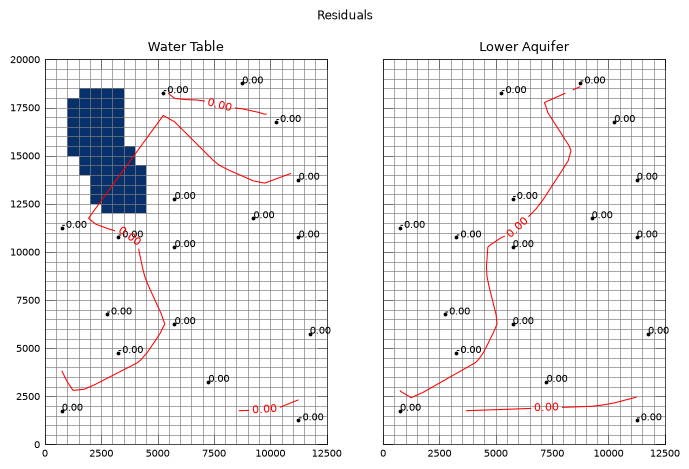

In [78]:
with flopy.plot.styles.USGSMap():
    fig, axs = plt.subplots(1, 2, figsize=(8, 5), sharey=True)
    fig.suptitle("Residuals")

    ax = axs[0]
    ax.set_xlim(0, 12500)
    ax.set_ylim(0, 20000)
    mm = flopy.plot.PlotMapView(model=gwf, ax=ax, extent=gwf.modelgrid.extent)
    mm.plot_array(lake_location, cmap="Blues_r", masked_values=[0])
    mm.plot_grid(lw=0.5, color="0.5")
    ax.scatter(x, y, s=3, c="black")
    for i, txt in enumerate(resid_wt):
        ax.annotate(f"{txt:.2f}", (x[i], y[i]))
    cs = ax.contour(
        grid_x,
        grid_y,
        grid_resid_wt,
        levels=resid_levels,
        linewidths=0.75,
        colors="red",
    )
    plt.clabel(cs, inline=True, fontsize=8)
    ax.set_title("Water Table")

    ax = axs[1]
    ax.set_xlim(0, 12500)
    ax.set_ylim(0, 20000)
    mm = flopy.plot.PlotMapView(model=gwf, ax=ax, extent=gwf.modelgrid.extent)
    mm.plot_grid(lw=0.5, color="0.5")
    ax.scatter(x, y, s=3, c="black")
    for i, txt in enumerate(resid_aq):
        ax.annotate(f"{txt:.2f}", (x[i], y[i]), clip_on=False)
    cs = ax.contour(
        grid_x,
        grid_y,
        grid_resid_aq,
        levels=resid_levels,
        linewidths=0.75,
        colors="red",
    )
    plt.clabel(cs, inline=True, fontsize=8)
    ax.set_title("Lower Aquifer")

**NOTE:** There is spatial bias in the simulated results (*i.e.*, residuals are positive in the Northeast and negative in the Southwest).

#### First 10-year transient period

Simulated heads and drawdown at the end of the first transient prediction period.

In [79]:
totim = totim_end[0]
totim1 = totim_end[1]

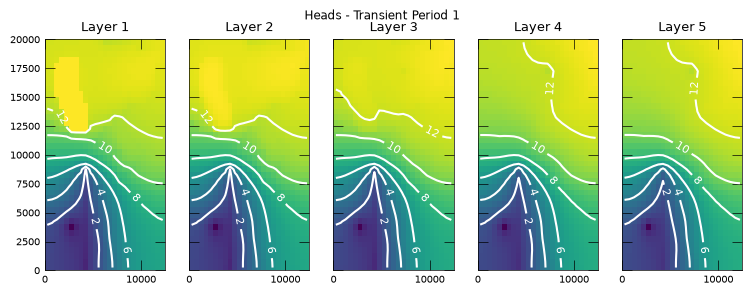

In [80]:
with flopy.plot.styles.USGSMap():
    fig, axs = plt.subplots(1, 5, figsize=(9, 3), sharey=True)
    fig.suptitle("Heads - Transient Period 1")
    hds = get_heads(totim1)

    for idx in range(nlay):
        ax = axs[idx]
        mm = flopy.plot.PlotMapView(model=gwf, layer=idx, ax=ax)
        mm.plot_array(hds)
        cs = mm.contour_array(hds, colors="white", levels=levels)
        plt.clabel(cs, inline=True, fontsize=8)
        ax.set_title(f"Layer {idx + 1}")

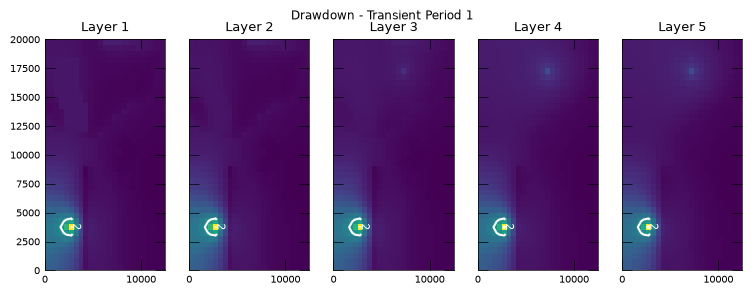

In [81]:
with flopy.plot.styles.USGSMap():
    fig, axs = plt.subplots(1, 5, figsize=(9, 3), sharey=True)
    fig.suptitle("Drawdown - Transient Period 1")
    ddn = get_heads(totim) - get_heads(totim1)

    ddn_max = ddn[:, 16, :].max()

    for idx in range(nlay):
        ax = axs[idx]
        mm = flopy.plot.PlotMapView(model=gwf, layer=idx, ax=ax)
        mm.plot_array(ddn)
        cs = mm.contour_array(ddn, colors="white", levels=levels)
        plt.clabel(cs, inline=True, fontsize=8)
        ax.set_title(f"Layer {idx + 1}")

In [82]:
print(f"Maximum Drawdown: {ddn_max}")

Maximum Drawdown: 0.2848051329771799


In [83]:
v = gwf.output.budget().get_data(text=riv_text, totim=totim1)[0]["q"]
print(f"Induced river infiltration: {np.all(v > 0)}\n{v}")

Induced river infiltration: False
[-105692.8445991   -79827.24974639  -84417.64375772  -85619.27948409
  -78237.723674    -69089.60250163  -62286.64017999  -55064.1854225
  -47942.20804487  -41609.29925303  -39196.36972785  -40298.76905387
  -45821.4089437   -48903.16449296  -50366.86878596  -51687.88872283
  -52893.01689965  -58959.83409397]


**What to look for — drawdown.** "Drawdown" here is the calibration-period head minus the later head, so positive values mark places where the water table has dropped. The cone of drawdown is centered on the pumping wells and is deepest in the pumped layers. The *induced river infiltration* check confirms that lowering heads near the stream pulls additional water in from it — the stream is helping to supply the wells.

#### Second 10-year transient period

Simulated heads and drawdown at the end of the second transient prediction period.

In [84]:
totim2 = totim_end[2]

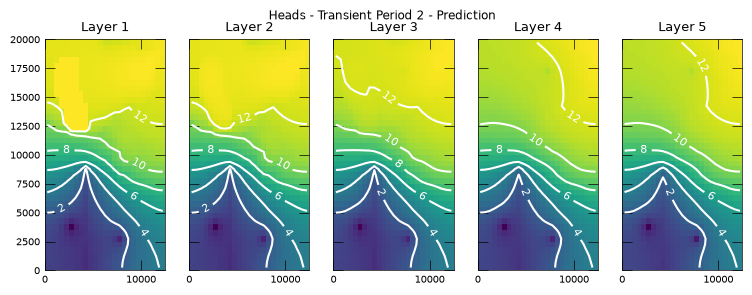

In [85]:
with flopy.plot.styles.USGSMap():
    fig, axs = plt.subplots(1, 5, figsize=(9, 3), sharey=True)
    fig.suptitle("Heads - Transient Period 2 - Prediction")
    hds = get_heads(totim2)

    for idx in range(nlay):
        ax = axs[idx]
        mm = flopy.plot.PlotMapView(model=gwf, layer=idx, ax=ax)
        mm.plot_array(hds)
        cs = mm.contour_array(hds, colors="white", levels=levels)
        plt.clabel(cs, inline=True, fontsize=8)
        ax.set_title(f"Layer {idx + 1}")

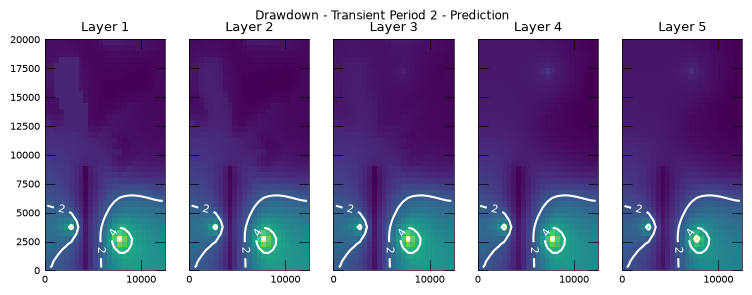

In [86]:
with flopy.plot.styles.USGSMap():
    fig, axs = plt.subplots(1, 5, figsize=(9, 3), sharey=True)
    fig.suptitle("Drawdown - Transient Period 2 - Prediction")
    ddn = get_heads(totim) - get_heads(totim2)

    ddn_max = ddn[:, 16, :].max()

    for idx in range(nlay):
        ax = axs[idx]
        mm = flopy.plot.PlotMapView(model=gwf, layer=idx, ax=ax)
        mm.plot_array(ddn)
        cs = mm.contour_array(ddn, colors="white", levels=levels)
        plt.clabel(cs, inline=True, fontsize=8)
        ax.set_title(f"Layer {idx + 1}")

In [87]:
print(f"Maximum Drawdown: {ddn_max}")

Maximum Drawdown: 0.9382811143051946


In [88]:
v = gwf.output.budget().get_data(text=riv_text, totim=totim2)[0]["q"]
print(f"Induced river infiltration: {np.all(v > 0)}\n{v}")

Induced river infiltration: False
[-93327.67318877 -67855.86346218 -69216.89258837 -67973.95682374
 -59984.68973748 -50452.93874517 -42416.11583014 -34008.99953388
 -25742.363617   -18219.68683222 -13775.21932978 -13806.50129183
 -17355.89177759 -20709.27135902 -23374.20957797 -25804.46824814
 -28073.82276069 -33249.31673924]


### Streamflow results

Streamflow at the southern boundary gage and the percent reduction in discharge caused by pumping.

In [89]:
if isSFR:
    df = gwf.sfr.output.obs().get_dataframe(start_datetime=start_date)
    df["RIV-FLOW"] /= -86400
else:
    df = gwf.riv.output.obs().get_dataframe()

df["RIV-SWGW"] /= -86400
df["TOTAL"] = df["RIV-SWGW"]

Q0 = df["TOTAL"].iloc[0]
df["PCT_DIFF"] = -100.0 * (df["TOTAL"] - Q0) / Q0
df

,totim,RIV-SWGW,RIV-FLOW,TOTAL,PCT_DIFF
2006-01-01,16071.0,16.057595,15.458721,16.057595,-0.000000
2007-01-01,16436.0,13.960415,13.518533,13.960415,13.060363
2008-01-01,16801.0,10.324502,9.803951,10.324502,35.703311
2009-01-01,17167.0,13.335625,12.880641,13.335625,16.951293
2010-01-01,17532.0,14.164816,13.745863,14.164816,11.787437
2011-01-01,17897.0,12.658143,12.176426,12.658143,21.170366
2012-01-01,18262.0,13.786686,13.349723,13.786686,14.142269
2013-01-01,18628.0,12.013187,11.514036,12.013187,25.186886
2014-01-01,18993.0,13.632637,13.189311,13.632637,15.101624
2015-01-01,19358.0,13.798954,13.361032,13.798954,14.065873


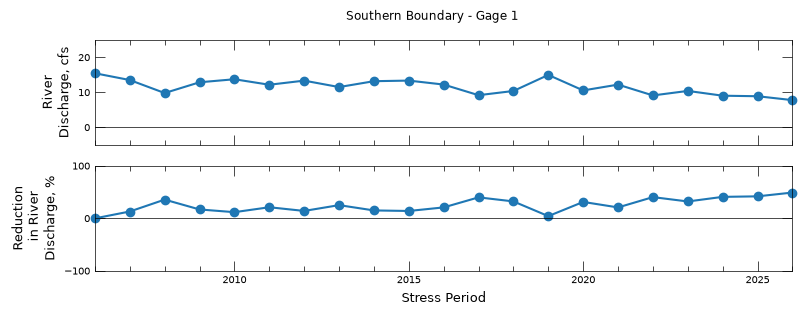

In [90]:
if isSFR:
    with flopy.plot.styles.USGSPlot():
        fig, axs = plt.subplots(2, 1, figsize=(9, 3), sharex=True)

        fig.suptitle("Southern Boundary - Gage 1")

        ax = axs[0]
        ax.set_ylim(-5, 25)
        df["RIV-FLOW"].plot(ax=ax, ls="-", marker="o", clip_on=False)
        ax.axhline(0, lw=0.5, color="black")
        ax.set_ylabel("River\nDischarge, cfs")

        ax = axs[1]
        ax.set_ylim(-100, 100)
        df["PCT_DIFF"].plot(ax=ax, ls="-", marker="o", clip_on=False)
        ax.axhline(0, lw=0.5, color="black")
        ax.set_ylabel("Reduction\n in River\nDischarge, %")
        ax.set_xlabel("Stress Period")
else:
    print("isSFR = " + str(isSFR))

**What to look for.** The top panel is discharge at the southern gage; the bottom panel is its percent reduction relative to the first stress period. As pumping continues, gage discharge falls and the percent reduction climbs — this is **streamflow capture**, the share of pumped water that comes at the expense of the stream rather than from aquifer storage. (This figure is drawn only when `isSFR` is `True`.)

### Lake stage

Simulated lake stage through time.

In [91]:
# Lake stage is written to the same observation file in both cases: the LAK
# package writes it when isLake is True, and the base model's GWF-OBS package
# writes the head in the high-K lake cell when isLake is False.

fpth = advanced_ws / f"{name}.lake.obs.csv"

In [92]:
lake_df = flopy.utils.Mf6Obs(fpth).get_dataframe(start_datetime=start_date)

In [93]:
if isLake:
    lake_df["LAKE-SWGW"] *= 12.0 / lake_area

In [94]:
lake_df

,totim,LAKE-STAGE,LAKE-SWGW
2006-01-01,16071.0,14.066031,0.077675
2007-01-01,16436.0,14.032999,0.078862
2008-01-01,16801.0,13.503891,0.074705
2009-01-01,17167.0,13.648804,0.069196
2010-01-01,17532.0,13.794423,0.071332
2011-01-01,17897.0,13.766150,0.074128
2012-01-01,18262.0,13.841530,0.073706
2013-01-01,18628.0,13.699110,0.074335
2014-01-01,18993.0,13.791643,0.072629
2015-01-01,19358.0,13.861270,0.074161


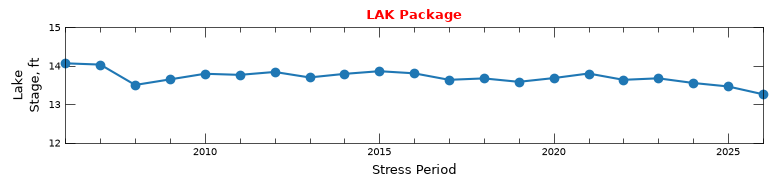

In [97]:
with flopy.plot.styles.USGSPlot():
    fig, ax = plt.subplots(1, 1, figsize=(9, 1.5))

    lake_df["LAKE-STAGE"].plot(
        ax=ax,
        ls="-",
        marker="o",
        clip_on=False,
    )
    ax.axhline(0, lw=0.5, color="black")
    if not isLake:
        ax.set_title("From high K cell", color='red', fontweight="bold")
    else:
        ax.set_title("LAK Package", color='red', fontweight="bold")
        
    ax.set_ylabel("Lake\nStage, ft")
    ax.set_xlabel("Stress Period")
    ax.set_ylim(12, 15)

**What to look for.** Lake stage drops as nearby pumping lowers groundwater levels and the lake gives up water to the aquifer. Whether this value comes from the `LAK` package (`isLake = True`) or from the head in the high-K lake cell of the base model, it is read from the same observation file, so the plot works either way.

**Recap.** Starting from a calibrated base model, you replaced its simple boundary conditions with advanced packages — `UZF` for recharge, `MAW` for wells, `SFR` for the river, and `LAK` for the lake — and tied them together with the `MVR` mover, each built from the same packagedata / connectiondata / perioddata pattern. You then ran the model and evaluated it against calibration targets and across two prediction periods, looking at head residuals, pumping-induced drawdown, streamflow capture, and lake stage. The toggle flags let you turn each upgrade on or off and re-run to see exactly what it changes.

In [96]:
isLake

True